**word2vec: извлечение признаков из текста на естественном языке**

Евгений Борисов <esborisov@sevsu.ru>

---

Jay Alammar Word2vec в картинках. (перевод - Анатолий Ализар)   
https://habr.com/ru/articles/446530/

Евгений Борисов О методе кодирования слов word2vec.   
http://mechanoid.su/ml-w2v.html

# загружаем текст 

In [1]:
import gzip
import requests
from bs4 import BeautifulSoup

url='http://lib.ru/NEWPROZA/LOBAS/taxisty.txt'
text = BeautifulSoup(requests.get(url).text).get_text()
with gzip.open('taxisty.txt.gz','wt') as f: f.write(text)

In [2]:
# import gzip
# with gzip.open('taxisty.txt.gz','rt') as f: text = f.read()

In [3]:
text = text[333:-7261].strip() # выкидываем заголовок и хвост страницы 
print(f'символов:{len(text)}\n--------------\n'%())
print(text[:355])

символов:638465
--------------

ЖЕЛТЫЕ КОРОЛИ 
     Записки нью-йоркского таксиста


     Товарищам моим -- белым и черным, американцам и эмигрантам  из России и
Израиля,  из  Греции  и  Кореи,  арабам,  китайцам,  полякам  и всем  прочим
таксистам города  Нью-Йорк  в знак глубокого  уважения к  их нечеловеческому
труду эту горькую книгу посвящаю...

     Водитель No 320718
     

   


# собираем датасет

## выполняем токенизацию

In [4]:
import numpy as np
from numpy import random as rng
import re

In [5]:
from nltk import __version__ as nltk_version
print('nltk version:',nltk_version)

nltk version: 3.9.1


In [6]:
from nltk.tokenize import sent_tokenize as nltk_sentence_split
from nltk.tokenize import word_tokenize as nltk_tokenize_word
from nltk.corpus import stopwords as nltk_stopwords

In [7]:
from random import sample

In [8]:
# выполняем токенизацию
sentences = [ 
    [ # разбираем предложения на отдельные слова
     t.lower() for t in nltk_tokenize_word(s) 
     if re.match(r'[а-я -]+',t.lower()) and len(t)>1 # выкидываем цифры, отдельные символы и т.п. 
    ] 
    for s in nltk_sentence_split(text) # режем текст на отдельные предложения
    if len(s.strip())>5
]

display(f'предложений: {len(sentences)}')

'предложений: 6584'

In [9]:
context_len = 2 # размер правого и левого контекста

In [10]:
# выкидываем очень короткие предложения
sentences = [ s for s in sentences if len(s)>context_len*2 ]
display(f'предложений: {len(sentences)}')

'предложений: 5009'

In [11]:
# ограничиваем датасет для ускорения процесса

# sentences = sentences[:256]
sentences = sample( sentences,256)
display( sample(sentences,3) )

[['мои',
  'мышцы',
  'напряжены',
  'до',
  'предела',
  'но',
  'только',
  'тогда',
  'когда',
  'совсем',
  'уже',
  'выбиваюсь',
  'из',
  'сил',
  'до',
  'меня',
  'доходит',
  'что',
  'на',
  'самом',
  'деле',
  'не',
  'помогаю',
  'бедняге',
  'мешаю',
  'ему'],
 ['однако',
  'черный',
  'кэбби',
  'открыл',
  'заднюю',
  'дверцу',
  'моего',
  'чекера',
  'переспросил',
  'пассажирки',
  'адрес',
  '--',
  'направился',
  'своей',
  'машине'],
 ['--', 'звякали', 'квотеры', 'большое', 'спасибо']]

## словарь

In [12]:
words = sorted(set(sum(sentences,[]))) # список слов из текста
vocab =  { w:i for i,w in enumerate(words) } # пронумерованный словарь 
del words

In [13]:
n_words = len(vocab) # количество слов в словаре
display( f'размер словаря: {n_words} слов')

'размер словаря: 2159 слов'

In [14]:
display( sample(list(vocab.keys()),9) )

['георгия',
 'привычной',
 'примеру',
 'руками',
 'приходиться',
 'излагал',
 'парк',
 'сказала',
 'рыбой']

## собираем контексты

In [15]:
from nltk.util import ngrams as nltk_ngrams

ngram_len = context_len*2+1 # длинна n-gram'ы

text_ngrams = [ 
        ngram for s in sentences if len(s)>ngram_len
        for ngram in nltk_ngrams(s,ngram_len) 
    ]
display('количество n-gram: %i'%(len(set(text_ngrams))))

sample(text_ngrams,5)

'количество n-gram: 2749'

[('знал', 'какое', 'мы', 'не', 'дослышали'),
 ('рост', 'плиты', 'на', 'меня', 'глядел'),
 ('промчалась', 'машина', 'царапавшая', 'душу', 'тревога'),
 ('по', 'одному', 'центу', '--', 'эй'),
 ('что', 'если', 'они', 'сейчас', 'подерутся')]

## кодируем слова

In [16]:
# заменяем слова на номера по словарю
T = np.array([ [ vocab[w] for w in ngrams ] for ngrams in text_ngrams ]) 

In [17]:
T

array([[1030,  194,  144, 1939,    0],
       [ 194,  144, 1939,    0, 1412],
       [ 167, 1032,  521, 2034, 2144],
       ...,
       [1315,  889, 1975,  907,  590],
       [ 889, 1975,  907,  590, 1133],
       [1975,  907,  590, 1133,  553]], shape=(2749, 5))

In [18]:
# отделяем слово от контекста

wn = ngram_len//2 # индекс середины n-gram'ы
W = T[:,wn] # вынимаем коды слов, которые будем предсказывать
C = np.delete(T,wn,axis=1) # коды слов левого и правого контекста
assert len(C) == len(W) # количество слов должно соответствовать контекстам

display( C.shape, W.shape )

(2749, 4)

(2749,)

In [19]:
del text_ngrams
del text
del T

In [20]:
# выполняем унитарное кодирование слов (one-hot-encoding)
E = np.eye(n_words,dtype=np.int8)
Wbin = np.vstack([ E[c] for c in W ])
Cbin = np.vstack([ np.vstack([ E[c] for c in Ci ])[np.newaxis,:] for Ci in C ]) 

display( Cbin.shape, Wbin.shape )

(2749, 4, 2159)

(2749, 2159)

In [21]:
del W
del C

# строим модель W2V

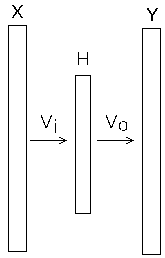

In [22]:
class Word2Vec:

    def __init__(self, vocab_size, embedding_size):
        self._Vi = rng.normal(scale=.01,size=(vocab_size,embedding_size))
        self._Vo = rng.normal(scale=.01,size=(embedding_size,vocab_size))

    def predict(self,w):
        return self._step(w)
        
    def _step(self,w):
        h = w.dot(self._Vi) # значения скрытого слоя
        # ф-ция активации скрытого слоя - линейная
        u = h.dot(self._Vo) # состояния выходного слоя
        o = self.softmax(u) # выход сети
        return h,u,o
  
    # ф-ция активации выходного слоя
    @staticmethod
    def softmax(s): 
        e = np.exp(s)
        return e/e.sum(axis=1).reshape(s.shape[0],1)        

In [23]:
# Word2Vec(vocab_size=Wbin.shape[-1], embedding_size=64).predict(Wbin[:2,:])

# обучаем W2V методом Skip-Gram

будем по контексту предсказывать слово

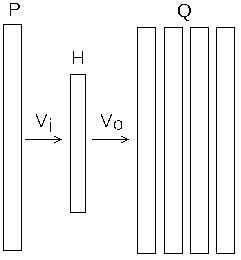

На вход сети подаётся код слова $P$, вычисляем состояние скрытого слоя $H$
$$H = P \cdot Vi$$

далее вычисляем выход сети $O$
$$U = H\cdot Vo$$
$$O = softmax(U)$$

для каждого слова контекста $Q_j$ и входа $P$
вычисляем ошибку $D$ на выходе сети $O$
и изменение весов сети $\Delta Vo_j$, $\Delta Vi_j$

$$D = O - Q_j$$
$$\Delta Vo_j =  H^T \cdot D$$
$$\Delta Vi_j =  D^T \cdot P \cdot {Vo}^T$$

вычисляем суммарное изменение весов сети $\Delta Vo$, $\Delta Vi$

$$\Delta Vo = \sum_j \Delta Vo_j$$
$$\Delta Vi = \sum_j \Delta Vi_j$$


Функция потери Skip-Gram на примере $i$

$$E_i = \left| \log\sum\exp(U_i) - \sum\sum_j(U_i * Q_{ij} ) \right|$$

$U_{i}$ состояние выходного слоя для слова $i$     
$Q_{ij}$ слово $j$ контекста слова $i$   
∗ - операция поэлементного умножения векторов

In [30]:
from tqdm.auto import tqdm

class SkipGram(Word2Vec):

    def fit( self, Wbin, Cbin, learning_rate=0.1, n_epoch=8 ):
        err = [ 1e10, ]
        for i in tqdm(range(n_epoch)):
            err_ = self._fit_epoch(Wbin,Cbin,learning_rate)
            err.append(err_)
            if self.early_stoping_condition(err): break
        return err[1:], self._Vo.T # , self._Vi

    def _fit_epoch(self,Wbin, Cbin,learning_rate):
        H,U,O = self._step(Wbin) # вычисляем состояния слоёв и выход
        err = self._loss(U,Cbin) # вычисляем ошибку
        gVi, gVo = self._grad(Cbin,Wbin,H,O) # вычисляем градиент ф-ции потери
        gVi,gVo = self.weigth_norm(gVi,gVo) # нормируем значения градиента
        
        # корректируем веса        
        self._Vi = self._Vi - learning_rate*gVi 
        self._Vo = self._Vo - learning_rate*gVo 

        return err

    @staticmethod
    def early_stoping_condition(err):
        return err[-1] > err[-2] 
    
    @staticmethod    
    def _loss(U,C):
        n,cws,v = C.shape 
        # n - количество примеров
        # cws - размер окна контекста   
        # v -количество слов в словаре
        Us = np.log( np.exp(U).sum(axis=1) ).sum()
        Uo = 0.0
        for i in range(cws): # для всех слов контекста
            Ci = C[:,i,:].reshape([n,v]) # набор слов контекста i
            Uo += (U*Ci).sum() # значения выходного слоя для слов x контекста i
        return np.abs(Us-Uo)/n    

    def _grad(self,C,W,H,O):
        n,cws,v = C.shape
        # n - количество примеров
        # cws - размер окна контекста   
        # v -количество слов в словаре
        gVi = gVo = 0.0 
        for i in range(cws):
            Ci = C[:,i,:].reshape([n,v]) # слово i контекста
            D = O - Ci # ошибка на слове контекста i
            gVo += D.T.dot(H).T
            gVi += W.T.dot(D).dot(self._Vo.T)
        return gVi,gVo       

    @staticmethod
    def weigth_norm(v,w):
        nn = np.linalg.norm( np.hstack([ v.flatten(), w.flatten() ]) )
        #nn = np.abs( np.hstack([ v.flatten(), w.flatten() ]) ).max()
        return (v/nn,w/nn) if nn!=0.0 else (v,w)        

In [25]:
%%time 

loss_history, w2v = SkipGram(
        vocab_size=Wbin.shape[-1], 
        embedding_size=64
    ).fit( 
        Wbin, 
        Cbin, 
        learning_rate=0.2, 
        n_epoch=256*2
    )

  0%|          | 0/512 [00:00<?, ?it/s]

CPU times: user 23min 4s, sys: 22.4 s, total: 23min 26s
Wall time: 4min 10s


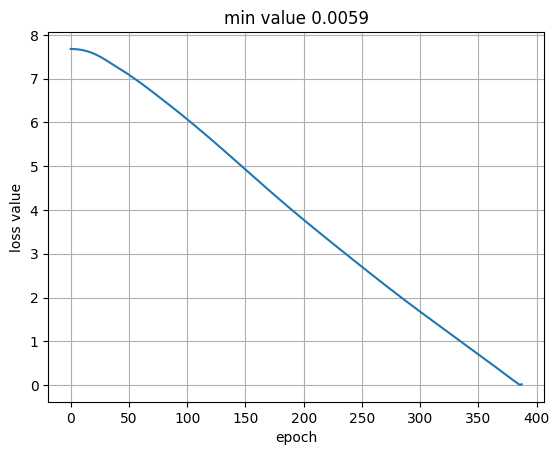

In [26]:
from matplotlib import pyplot as plt

fig,ax = plt.subplots()
ax.plot(loss_history)
ax.set_xlabel('epoch')
ax.set_ylabel('loss value')
ax.grid()
ax.set_title(f'min value {min(loss_history):.4f}')
plt.show()

# оцениваем результат

In [38]:
# from sklearn.metrics.pairwise import cosine_distances as metric
from sklearn.metrics.pairwise import euclidean_distances as metric

In [39]:
vocab_inv = { v:k for k,v in vocab.items() } # номера слов

In [40]:
indices = rng.randint( 0, len(vocab), 10 ) # выбираем случайно N слов
# матрица расстояний и номера слов в порядке увеличения расстояния
D = metric(w2v[indices,:],w2v) 
# R = np.argsort( D )[::-1] # cosine_distances
R = np.argsort( D )

# для выбранных слов печатаем близкие по w2v
display( {
    vocab_inv[i] : { 
        vocab_inv[j]: f'{D[n,j]:.2f}'
        for j in R[n,1:4] 
    } 
    for n,i in enumerate(indices) 
} )

{'капли': {'фиг': '0.19', 'опустилась': '0.20', 'собирался': '0.20'},
 'сказануть': {'такое': '0.19', 'желтый': '0.20', 'нужны': '0.20'},
 'сил': {'видел': '0.70', 'чекер': '0.71', 'водителей': '0.73'},
 'монологах': {'понять': '0.19', 'костров': '0.21', 'находимся': '0.22'},
 'новый': {'по-видимому': '0.15',
  'отшлифованными': '0.16',
  'мышлением': '0.16'},
 'попавшейся': {'первой': '0.15', 'телефонной': '0.16', 'тормознув': '0.17'},
 'работы': {'сквозь': '0.21', 'своему': '0.22', 'квотер': '0.25'},
 'обстоятельств': {'право': '0.20', 'стравил': '0.22', 'исподтишка': '0.22'},
 'немедленно': {'вспомнил': '0.31', 'постучался': '0.34', 'годами': '0.34'},
 'заглянул': {'кабину': '0.18', 'сказала': '0.20', 'доверху': '0.21'}}